In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns



current_dir = Path.cwd()
project_root = current_dir.parents[2]
# --- Cargar datos ---
path_data = project_root / 'DATA_PPMI/Results/MODEL_DATA/data_HY.csv'
data_HY = pd.read_csv(path_data, index_col=[0,1])

In [13]:
data_HY.head(10)

,,EVENT_ID,COHORT_DEFINITION,NHY
,PATNO,,,
12,3003,BL,Parkinson's Disease,2.0
13,3003,V04,Parkinson's Disease,2.0
14,3003,V06,Parkinson's Disease,2.0
15,3003,V08,Parkinson's Disease,2.0
16,3003,V10,Parkinson's Disease,3.0
48,3018,BL,Parkinson's Disease,2.0
49,3018,V04,Parkinson's Disease,2.0
50,3018,V06,Parkinson's Disease,2.0
51,3018,V08,Parkinson's Disease,2.0


In [14]:
# 1) Normaliza cohortes a etiquetas cortas

# 2) Filtra a las cohortes y visitas que quieres
visits = ["BL", "V04", "V06", "V08", "V10"]


data_HY = data_HY[
    data_HY["COHORT_DEFINITION"].isin(["Parkinson's Disease", "Prodromal"]) &
    data_HY["EVENT_ID"].isin(visits)
].copy()

# 3) Asegura NHY 0-5 (por si viene como 0.0/1.0)
data_HY = data_HY[data_HY["NHY"].isin([0,1,2,3,4,5])].copy()
data_HY["NHY"] = data_HY["NHY"].astype(int)

# 4) Tabla pivote de conteos
tab = (
    data_HY.groupby(["EVENT_ID", "COHORT_DEFINITION", "NHY"])
      .size()
      .unstack("NHY", fill_value=0)
      .reindex(columns=[0,1,2,3,4,5], fill_value=0)
)

# 5) Total por fila
tab["Total"] = tab.sum(axis=1)

tab

NHY                             0    1    2   3  4  5  Total
EVENT_ID COHORT_DEFINITION                                  
BL       Parkinson's Disease    1  105  147   5  0  0    258
         Prodromal            236    6    3   0  0  0    245
V04      Parkinson's Disease    1   66  180  10  1  0    258
         Prodromal            227   11    7   0  0  0    245
V06      Parkinson's Disease    1   51  195   9  2  0    258
         Prodromal            227    8    8   2  0  0    245
V08      Parkinson's Disease    0   42  206   8  1  1    258
         Prodromal            216   18   11   0  0  0    245
V10      Parkinson's Disease    3   32  201  19  2  1    258
         Prodromal            216   16   11   2  0  0    245

In [15]:
def HY_classification(nhy):
    if nhy == 0 :
        return 'Healthy'
    elif nhy in [1,2] :
        return 'Early Stage'
    else:
        return 'Advanced Stage'

data_HY['STAGE'] = data_HY['NHY'].apply(HY_classification)
data_HY.head(10)

,,EVENT_ID,COHORT_DEFINITION,NHY,STAGE
,PATNO,,,,
12,3003,BL,Parkinson's Disease,2,Early Stage
13,3003,V04,Parkinson's Disease,2,Early Stage
14,3003,V06,Parkinson's Disease,2,Early Stage
15,3003,V08,Parkinson's Disease,2,Early Stage
16,3003,V10,Parkinson's Disease,3,Advanced Stage
48,3018,BL,Parkinson's Disease,2,Early Stage
49,3018,V04,Parkinson's Disease,2,Early Stage
50,3018,V06,Parkinson's Disease,2,Early Stage
51,3018,V08,Parkinson's Disease,2,Early Stage


In [16]:
data_HY.loc[data_HY['EVENT_ID'] == 'BL', 'COHORT_DEFINITION'].value_counts()

COHORT_DEFINITION
Parkinson's Disease    258
Prodromal              245
Name: count, dtype: int64

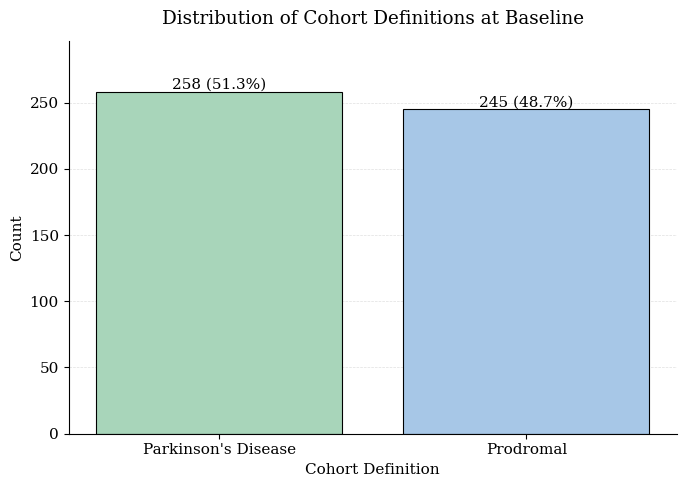

In [17]:

# Filtrar y contar
counts = (
    data_HY.loc[data_HY['EVENT_ID'] == 'BL', 'COHORT_DEFINITION']
    .value_counts()
)

total = counts.sum()
percentages = counts / total * 100

# Definir colores específicos
color_map = {
    "Prodromal": "#A7C7E7",   # azul pastel
    "Parkinson": "#A8D5BA"    # verde pastel
}

colors = [color_map.get(cat, "#A8D5BA") for cat in counts.index]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    counts.index,
    counts.values,
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Añadir count + porcentaje encima
for bar, count, pct in zip(bars, counts.values, percentages):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{count} ({pct:.1f}%)",
        ha='center',
        va='bottom'
    )

ax.set_title("Distribution of Cohort Definitions at Baseline", pad=12)
ax.set_xlabel("Cohort Definition")
ax.set_ylabel("Count")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)

plt.xticks(rotation=0)

# Añadir pequeño margen superior para que no se corte el texto
ax.set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3371077/318468896.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts_df['Stage'], rotation=0, ha='center')


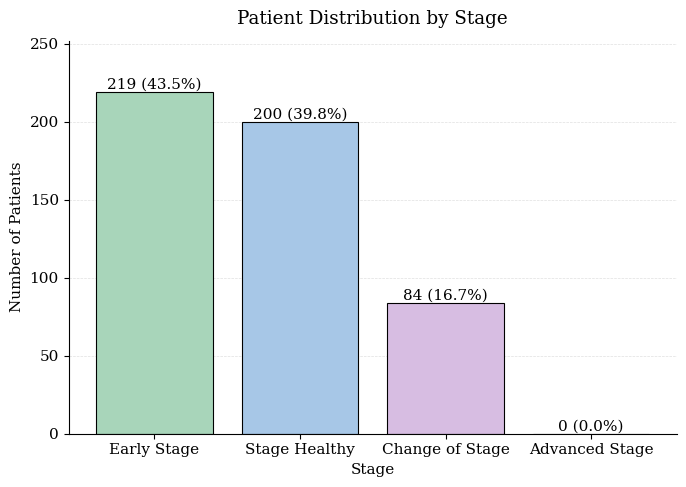

In [18]:
data_HY.reset_index('PATNO', inplace=True)
counts = {'Stage Healthy': 0, 'Early Stage': 0, 'Advanced Stage': 0,'Change of Stage': 0}
for patno in data_HY['PATNO'].unique():
    subset_data = data_HY[data_HY['PATNO'] == patno]
    stages = subset_data['STAGE'].unique()
    
    if len(stages) > 1:
        counts['Change of Stage'] += 1
    else:
        if stages[0] == 'Healthy':
            counts['Stage Healthy'] += 1
        elif stages[0] == 'Early Stage':
            counts['Early Stage'] += 1
        elif stages[0] == 'Advanced Stage':
            counts['Advanced Stage'] += 1


# Convertir a DataFrame
counts_df = pd.DataFrame(list(counts.items()), columns=['Stage', 'Count'])

# (Opcional) ordenar por conteo descendente
counts_df = counts_df.sort_values('Count', ascending=False)

total = counts_df['Count'].sum()
counts_df['Pct'] = counts_df['Count'] / total * 100

# Colores pastel por categoría (ajusta a tu gusto)
color_map = {
    "Stage Healthy": "#A7C7E7",      # azul pastel
    "Early Stage": "#A8D5BA",        # verde pastel
    "Advanced Stage": "#F7C59F",     # naranja pastel
    "Change of Stage": "#D7BDE2"     # lila pastel
}
colors = [color_map.get(cat, "#D3D3D3") for cat in counts_df['Stage']]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    counts_df['Stage'],
    counts_df['Count'],
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Añadir count + porcentaje encima de cada barra
for bar, count, pct in zip(bars, counts_df['Count'], counts_df['Pct']):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{count} ({pct:.1f}%)",
        ha='center',
        va='bottom'
    )

ax.set_title("Patient Distribution by Stage", pad=12)
ax.set_xlabel("Stage")
ax.set_ylabel("Number of Patients")

# Estilo de ejes como tu ejemplo
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
ax.set_axisbelow(True)

# Rotación de etiquetas (pon 0 si te caben bien)
ax.set_xticklabels(counts_df['Stage'], rotation=0, ha='center')

# Margen arriba para que no se corte el texto
ax.set_ylim(0, counts_df['Count'].max() * 1.15)

plt.tight_layout()
plt.show()